## Importation des bibliothèques

In [4]:
import pandas as pd
from great_tables import GT
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import io
import geopandas as gpd
from shapely.geometry import Point
import folium

## Importation de la base de données

In [5]:
# Récupération des données via l'url accessible sur : https://www.data.gouv.fr/datasets/recensement-des-equipements-sportifs-espaces-et-sites-de-pratiques
# Chargement long

# data = pd.read_csv("https://www.data.gouv.fr/api/1/datasets/r/ea4f5879-af40-4e3e-949d-812d6eeb5e02")

# Récupération directement depuis le dernier csv téléchargé au préalable et stocké sur le s3

data = pd.read_csv("https://minio.lab.sspcloud.fr/matteo/data-es.csv", sep=";")
data.head(10)

/tmp/ipykernel_23987/2388994187.py:8: DtypeWarning: Columns (6,8,19,23,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("https://minio.lab.sspcloud.fr/matteo/data-es.csv", sep=";")


,equip_numero,inst_numero,inst_enqu_date,inst_nom,inst_siret,inst_adresse,inst_cp,new_name,new_code,inst_part_type_filter,...,equip_pshs_trib,equip_pshs_vest,equip_x,equip_y,inst_part_type,aps_name,equip_qpv,equip_qpv_200m,categorie,gen_2024fin_labellisation
0,E001I690130008,I690130008,2025-03-31,"Complexe sportif ""espace grange moulin""",2.169001e+13,2500 route de longsard,69400,Arnas,69013,Complexe sportif,...,False,False,4.699920,46.027570,"[""Complexe sportif""]","Activités de forme et de santé,Judo / Jujitsu ...",NaN,NaN,structurant,NaN
1,E005I352970009,I352970009,2025-03-31,Complexe sportif extérieur,2.135030e+13,Rue du Stade,35290,Saint-Méen-le-Grand,35297,Complexe sportif,...,False,False,-2.195597,48.187456,"[""Complexe sportif""]",Tennis,NaN,NaN,NaN,NaN
2,E003I973090057,I973090057,2025-03-31,Sporty training 54,9.833028e+13,3 rue Eugène PAJO,97354,Remire-Montjoly,97309,NaN,...,False,False,-52.276054,4.889464,NaN,"Activités de forme et de santé,Football / Foot...",NaN,NaN,proximité,NaN
3,E001I690130009,I690130009,2025-03-31,Nutrifit'Studio,NaN,71 Rue de Prairie,69400,Arnas,69013,NaN,...,False,False,4.726686,46.009865,NaN,Autres Danses,NaN,NaN,NaN,NaN
4,E005I353000003,I353000003,2025-03-31,Base de loisirs de la Haute-Vilaine,2.000390e+13,La petite ville cuite,35500,Saint-M'Hervé,35300,NaN,...,False,False,-1.119803,48.150394,NaN,Vtt (Cross Country/ Descente/ Trial/ Rallye/ F...,NaN,NaN,proximité,NaN
5,E001I690130010,I690130010,2025-03-31,Complexe de l'Escale,2.000406e+13,2726 route de Longsard,69400,Arnas,69013,NaN,...,False,False,4.697937,46.029623,NaN,"Badminton,Jeu de volant,Basket-Ball,Handball /...",NaN,NaN,structurant,NaN
6,E005I353080002,I353080002,2025-03-31,Complexe sportif,NaN,Rue de l'Egalité,35720,Mesnil-Roc'h,35308,Complexe sportif,...,False,False,-1.906630,48.444570,"[""Complexe sportif""]","Judo-jujitsu,kendo et disciplines associees (A...",NaN,NaN,NaN,NaN
7,E001I690140003,I690140003,2025-03-31,TYROLIENNE,2.169001e+13,NaN,69610,Aveize,69014,NaN,...,False,False,4.477480,45.680390,NaN,Escalade sur PAH,NaN,NaN,NaN,NaN
8,E005I353120002,I353120002,2025-03-31,Les circuits de randonnées,2.135031e+13,rue des bateliers,35580,Saint-Senoux,35312,NaN,...,False,False,-1.789120,47.905700,NaN,"Randonnée pédestre,Vtt (Cross Country/ Descent...",NaN,NaN,NaN,NaN
9,E001I690150002,I690150002,2025-03-31,PARCOURS D'AVENTURE DU HAUT BEAUJOLAIS,2.000844e+13,sentier du pardon,69430,Deux-Grosnes,69135,NaN,...,False,False,4.594710,46.193230,NaN,Escalade dans les arbres,NaN,NaN,NaN,NaN


## Analyses descriptives

In [6]:
total_equipements = data.shape[0]
print(total_equipements)

333609


### Répartition par type d'équipements

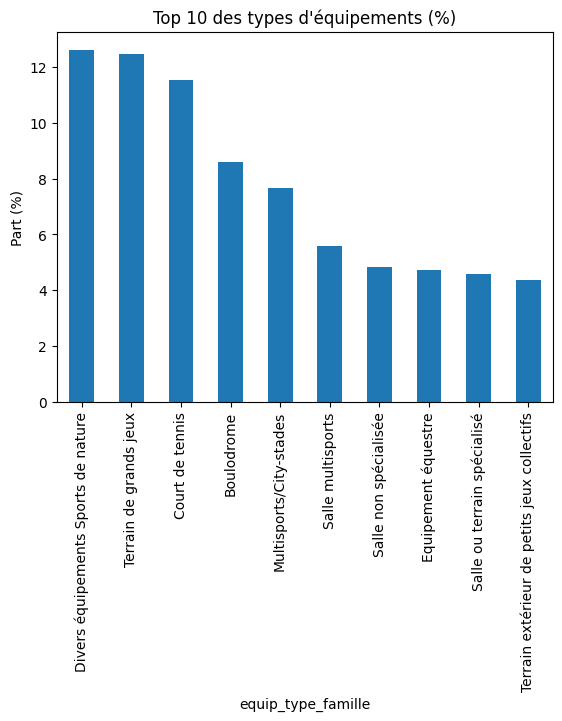

In [7]:
equip_types = (
    data['equip_type_famille']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

equip_types.head(10).plot(kind='bar')
plt.title("Top 10 des types d'équipements (%)")
plt.ylabel("Part (%)")
plt.show()

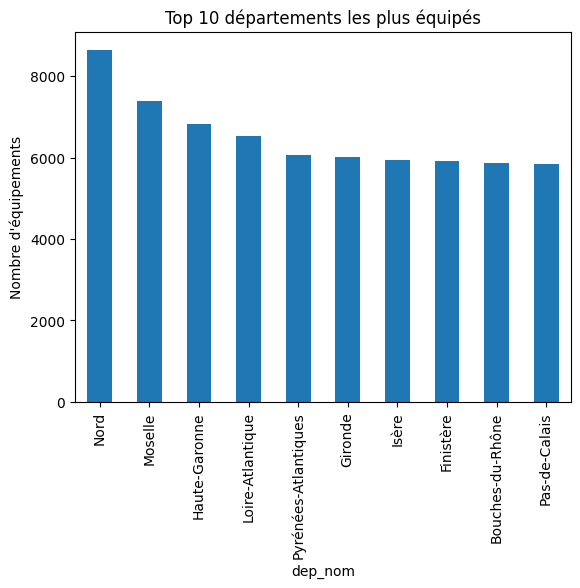

In [8]:
equip_dep = (
    data
    .groupby('dep_nom')
    .size()
    .sort_values(ascending=False)
)

equip_dep.head(10).plot(kind='bar')
plt.title("Top 10 départements les plus équipés")
plt.ylabel("Nombre d'équipements")
plt.show()

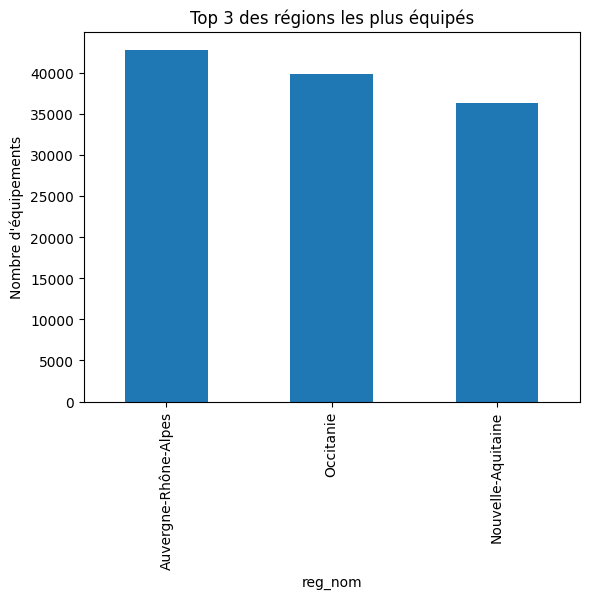

In [9]:
equip_reg = (
    data
    .groupby('reg_nom')
    .size()
    .sort_values(ascending=False)
)

equip_reg.head(3).plot(kind='bar')
plt.title("Top 3 des régions les plus équipés")
plt.ylabel("Nombre d'équipements")
plt.show()

### Génération d'une carte qui répértorie le nombre d'équipement par famille d'équipement

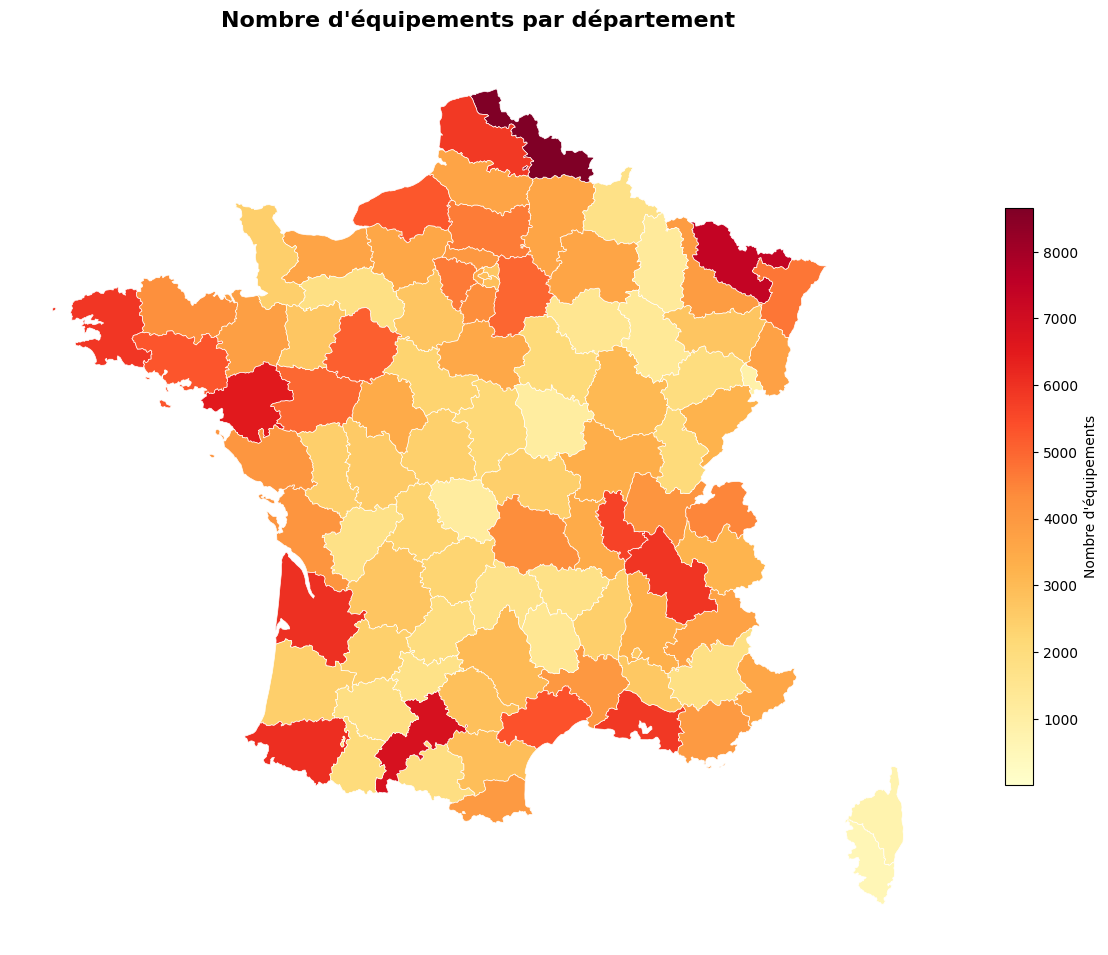

In [10]:
def plot_carte_nb_equipement_par_famille(famille=None):
    new_data = data.copy()
    if famille is not None:
        new_data = data[data['equip_type_famille'] == famille]
    equip_dep = (
    new_data
    .groupby('dep_nom')
    .size()
    .sort_values(ascending=False)
    )

    #1. Conversion de la Series en DataFrame
    df = equip_dep.reset_index()
    df.columns = ["departement", "valeur"]

    #2. Téléchargement du GeoJSON
    url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
    response = requests.get(url)
    gdf = gpd.read_file(io.BytesIO(response.content))

    #3. Fusion
    gdf = gdf.merge(df, left_on="nom", right_on="departement", how="left")

    #4. Carte 
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    gdf.plot(
        column="valeur",
        ax=ax,
        cmap="YlOrRd",
        legend=True,
        legend_kwds={
            "label": "Nombre d'équipements",
            "orientation": "vertical",
            "shrink": 0.6,
        },
        missing_kwds={
            "color": "#e0e0e0",
            "label": "Données manquantes"
        },
        edgecolor="white",
        linewidth=0.5,
        vmin=df["valeur"].min(),
        vmax=df["valeur"].max()
    )

    ax.set_title("Nombre d'équipements par département", fontsize=16, fontweight="bold", pad=15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_carte_nb_equipement_par_famille()


## Zoom sur l'ensemble des équipements "nautiques"

In [11]:
data_nautique = data[data['equip_type_famille'] == "Site d'activités aquatiques et nautiques"]


colonnes = ['equip_numero', "inst_numero", "inst_nom", "inst_adresse", "inst_cp", "dep_code", "reg_code", "dep_nom", "reg_nom", "lib_bdv", "equip_nom", "equip_type_name", "equip_coordonnees", "aps_name"]
data_nautique = data_nautique[colonnes].reset_index(drop=True).copy()
mots = ["surf", "ski", "voile", "foil", "wake"]
pattern = "|".join(mots)
data_nautique = data_nautique[data_nautique['aps_name'].str.contains(pattern, case=False, na=False)]
data_nautique['dep_code'] = data_nautique['dep_code'].astype(str)
data_nautique

,equip_numero,inst_numero,inst_nom,inst_adresse,inst_cp,dep_code,reg_code,dep_nom,reg_nom,lib_bdv,equip_nom,equip_type_name,equip_coordonnees,aps_name
4,E003I974130041,I974130041,Baie de St Leu,rue de la Campagnie des Indes,97416,974,4.0,La Réunion,La Réunion,Saint-Leu,La Cafrine,Site d'activités aquatiques et nautiques,"-21.1867, 55.2866",Surf
5,E003I974130046,I974130046,Cimetière de St Leu,RN 1 Grand Fond,97416,974,4.0,La Réunion,La Réunion,Saint-Leu,Le cimetière,Site d'activités aquatiques et nautiques,"-21.1858, 55.287",Surf
8,E001I690640001,I690640001,BASE DE LOISIRS DE CONDRIEU,LA PRESQU'ILE,69420,69,84.0,Rhône,Auvergne-Rhône-Alpes,Condrieu,Base de loisirs-plan d'eau,Site d'activités aquatiques et nautiques,"45.45552, 4.77446","Canoë de randonnée,Téléski nautique"
15,E004I011840003,I011840003,CHAMBOD - CENTRE UDPA,NaN,1250,1,84.0,Ain,Auvergne-Rhône-Alpes,Ceyzériat,SITE MIXTE,Site d'activités aquatiques et nautiques,"46.12417, 5.42917","Baignade loisirs,Canoë de randonnée,Kayak-polo..."
17,E005I412690005,I412690005,COMPLEXE SPORTIF DES GRANDS PRES,Rue Geoffroy Martel,41100,41,24.0,Loir-et-Cher,Centre-Val de Loire,Vendôme,Base nautique des Grands Prés,Site d'activités aquatiques et nautiques,"47.79099, 1.0741","Canoë de randonnée,Planche à Voile"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11570,E006I581800003,I581800003,Base Nautique des Settons,Lac des Settons D 193 Montsauche les settons,58230,58,27.0,Nièvre,Bourgogne-Franche-Comté,Saulieu,Base de plein air multiactivités,Site d'activités aquatiques et nautiques,"47.18739, 4.0643","Aviron,Canoë de randonnée,Dériveur / Multicoqu..."
11576,E006I721820001,I721820001,Espace touristique du lac de Mansigné,Route de Plessis,72510,72,52.0,Sarthe,Pays de la Loire,Écommoy,Plan d'eau,Site de pêche,"47.75788, 0.13017",Dériveur / Multicoques / Courses océaniques / ...
11583,E004I880820003,I880820003,Pôle sports nature,La grande haie,88110,88,44.0,Vosges,Grand Est,Raon-l'Étape,Site d'activités aquatiques,Site d'activités aquatiques et nautiques,"48.4565, 6.95106","Baignade loisirs,Canoë de randonnée,Planche à ..."
11585,E004I890240043,I890240043,Base nautique de VAUX,22 Rue du poiry Vaux,89000,89,27.0,Yonne,Bourgogne-Franche-Comté,Auxerre,Base de ski nautique - Rte de Poiry,Stade de ski nautique,"47.76078, 3.59631",Ski nautique classique / Course / à figures li...


### Création de la carte folium

In [12]:
# Séparer lat/lon (si equip_coordonnees est du type "lat, lon")
data_nautique[['lat', 'lon']] = data_nautique['equip_coordonnees'].str.split(',', expand=True).astype(float)

data_nautique['lat'] = data_nautique['lat'].dropna()
data_nautique['lon'] = data_nautique['lon'].dropna()
data_nautique['equip_nom'] = data_nautique['equip_nom'].dropna()
# Créer le GeoDataFrame
geometry = [Point(lon, lat) for lat, lon in zip(data_nautique['lat'], data_nautique['lon'])]
gdf = gpd.GeoDataFrame(data_nautique, geometry=geometry, crs=2154)

In [13]:
m = folium.Map(location=[46.6, 2.3], zoom_start=6)

for _, row in data_nautique.dropna(subset=['lat', 'lon']).iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=row['aps_name']
    ).add_to(m)

#m

In [14]:
# Nombre d'équipements par département
tab_dep = (
    data_nautique
    .groupby('dep_nom')
    .size()
    .reset_index(name='nb_equipements')
)
tab_dep

,dep_nom,nb_equipements
0,Ain,21
1,Aisne,11
2,Allier,5
3,Alpes-Maritimes,75
4,Alpes-de-Haute-Provence,8
...,...,...
101,Vienne,6
102,Vosges,4
103,Wallis-et-Futuna,2
104,Yonne,10


In [15]:
# Top 3
top3 = tab_dep.nlargest(3, 'nb_equipements')

# Bottom 3
bottom3 = tab_dep.nsmallest(3, 'nb_equipements')

# Combiner
tab_final = pd.concat([top3, bottom3])

# Ajouter une colonne pour distinguer
tab_final['categorie'] = ['Top 3'] * 3 + ['Les 3 moins bons'] * 3

tab_final = tab_final.sort_values(
    by=['categorie', 'nb_equipements'],
    ascending=[False, False]
)

tab_final = tab_final.reset_index(drop=True)

tab_final

,dep_nom,nb_equipements,categorie
0,Morbihan,359,Top 3
1,Finistère,279,Top 3
2,Côtes-d'Armor,221,Top 3
3,Haute-Loire,1,Les 3 moins bons
4,Hautes-Pyrénées,1,Les 3 moins bons
5,Saint-Barthélemy,1,Les 3 moins bons


### Visualisation de la table finale

In [16]:
table = (
    GT(tab_final)
    .tab_header(
        title="Départements les plus et moins équipés d'équipements nautiques)",
        subtitle="Top 3 et Bottom 3 en nombre d'équipements"
    )
    .cols_label(
        dep_nom="Nom du département",
        nb_equipements="Nombre d'équipements",
        categorie="Catégorie"
    )
    .fmt_number(columns=['nb_equipements'], decimals=0)
    .data_color(
        columns=['nb_equipements'],
        palette=["lightblue", "darkblue"]
    )
)

table

GT(_tbl_data=            dep_nom  nb_equipements         categorie
0          Morbihan             359             Top 3
1         Finistère             279             Top 3
2     Côtes-d'Armor             221             Top 3
3       Haute-Loire               1  Les 3 moins bons
4   Hautes-Pyrénées               1  Les 3 moins bons
5  Saint-Barthélemy               1  Les 3 moins bons, _body=<great_tables._gt_data.Body object at 0x7fae484f1e80>, _boxhead=Boxhead([ColInfo(var='dep_nom', type=<ColInfoTypeEnum.default: 1>, column_label='Nom du département', column_align='left', column_width=None), ColInfo(var='nb_equipements', type=<ColInfoTypeEnum.default: 1>, column_label="Nombre d'équipements", column_align='right', column_width=None), ColInfo(var='categorie', type=<ColInfoTypeEnum.default: 1>, column_label='Catégorie', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fae484f0ec0>, _spanners=Spanners([]), _heading=Heading(title="Départements les plus et moins équipés d'équipements nautiques)", subtitle="Top 3 et Bottom 3 en nombre d'équipements", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fae484f1940>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fae3c6ad810>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='nb_equipements', rows=[0], mask=None), grpname=None, colname='nb_equipements', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#00008b')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[1], mask=None), grpname=None, colname='nb_equipements', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#27309f')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[2], mask=None), grpname=None, colname='nb_equipements', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#4353ae')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[3], mask=None), grpname=None, colname='nb_equipements', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[4], mask=None), grpname=None, colname='nb_equipements', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[5], mask=None), grpname=None, colname='nb_equipements', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')])], _locale=<great_tables._gt_data.Locale object at 0x7fae484f1be0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fae484f1fd0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', v